## DATA 620 - Web Analytics | Candace Grant
### Project 3 | Gender Classifier

This notebook builds a name gender classifier using the NLTK Names Corpus and a Naive Bayes Classifier, 
one of the three classifiers described in Chapter 6 of *Natural Language Processing with Python*. Naive Bayes was selected over Decision Tree and Maximum Entropy classifiers for its efficiency with sparse, high-dimensional feature spaces and its ability to surface interpretable feature importance rankings.

The corpus is split into three subsets:
- **Training set:** ~6,900 names (used to train the model)
- **Dev-test set:** 500 names (used to iteratively improve features)
- **Test set:** 500 names (used only for final evaluation)

Features are added incrementally, with dev-test accuracy checked after each improvement.

### Imports and Data Loading

In [3]:
import nltk
import random

# Download the names corpus if not already present
nltk.download('names', quiet=True)

from nltk.corpus import names

# Load all names with gender labels
labeled_names = (
    [(name, 'male') for name in names.words('male.txt')] +
    [(name, 'female') for name in names.words('female.txt')]
)

# Shuffle with a fixed seed for reproducibility
random.seed(42)
random.shuffle(labeled_names)

print(f"Total names: {len(labeled_names)}")
print(f"Sample: {labeled_names[:5]}")

Total names: 7944
Sample: [('Raye', 'female'), ('Marita', 'female'), ('Fey', 'female'), ('Vittoria', 'female'), ('Dannie', 'female')]


### Split the Corpus

Following the assignment instructions, I split the shuffled corpus into:
- **Test set:** first 500 names 
- **Dev-test set:** next 500 names (used to guide feature engineering)
- **Training set:** remaining names (~6,900)

### Data Split

In [4]:
test_names     = labeled_names[:500]
devtest_names  = labeled_names[500:1000]
train_names    = labeled_names[1000:]

print(f"Training set:  {len(train_names)}")
print(f"Dev-test set:  {len(devtest_names)}")
print(f"Test set:      {len(test_names)}")

Training set:  6944
Dev-test set:  500
Test set:      500


### Baseline Feature Extractor

I started with the simplest possible feature: the **last letter** of the name.
This mirrors the textbook's starting example.

### Iteration 1 — Baseline Classifier Using Last Letter Only

In [5]:
def gender_features_v1(name):
    """Baseline: last letter only."""
    return {'last_letter': name[-1].lower()}

# Build feature sets
train_set   = [(gender_features_v1(n), g) for (n, g) in train_names]
devtest_set = [(gender_features_v1(n), g) for (n, g) in devtest_names]

# Train Naive Bayes
classifier_v1 = nltk.NaiveBayesClassifier.train(train_set)

# Evaluate
devtest_acc_v1 = nltk.classify.accuracy(classifier_v1, devtest_set)
print(f"[v1 - last letter only] Dev-test accuracy: {devtest_acc_v1:.4f}")

# Show most informative features
classifier_v1.show_most_informative_features(10)

[v1 - last letter only] Dev-test accuracy: 0.7540
Most Informative Features
             last_letter = 'a'            female : male   =     31.8 : 1.0
             last_letter = 'k'              male : female =     28.6 : 1.0
             last_letter = 'f'              male : female =     26.8 : 1.0
             last_letter = 'p'              male : female =     12.0 : 1.0
             last_letter = 'd'              male : female =      9.7 : 1.0
             last_letter = 'o'              male : female =      8.9 : 1.0
             last_letter = 'm'              male : female =      8.7 : 1.0
             last_letter = 'v'              male : female =      8.6 : 1.0
             last_letter = 'r'              male : female =      7.0 : 1.0
             last_letter = 'g'              male : female =      5.1 : 1.0


**Result of the Baseline Feature Extractor + Classifier:** Dev-test accuracy = **0.7540**

Using only the last letter of each name, the classifier correctly predicted gender 75.4% of the time. 
The most informative features confirm strong signal in this single character: names ending in *'a'* 
are female at a 31.8:1 ratio, while names ending in *'k'* and *'f'* are male at 28.6:1 and 26.8:1 
respectively. This establishes the baseline — any feature added going forward must beat 75.4% on 
the dev-test set to be considered an improvement.

### Iteration 2 — Adding Bigram Suffixes to Improve Gender 
The most informative features from v1 are mostly suffixes. 
We now add the **last two letters** as an additional feature to capture common suffixes 
like *-na*, *-ia*, *-on*, *-rd*.

In [6]:
def gender_features_v2(name):
    """Add last two letters."""
    name = name.lower()
    return {
        'last_letter':  name[-1],
        'last_two':     name[-2:],
    }

train_set   = [(gender_features_v2(n), g) for (n, g) in train_names]
devtest_set = [(gender_features_v2(n), g) for (n, g) in devtest_names]

classifier_v2 = nltk.NaiveBayesClassifier.train(train_set)
devtest_acc_v2 = nltk.classify.accuracy(classifier_v2, devtest_set)
print(f"[v2 - last two letters] Dev-test accuracy: {devtest_acc_v2:.4f}")

classifier_v2.show_most_informative_features(10)

[v2 - last two letters] Dev-test accuracy: 0.7840
Most Informative Features
                last_two = 'na'           female : male   =     93.9 : 1.0
                last_two = 'la'           female : male   =     70.8 : 1.0
                last_two = 'rd'             male : female =     38.7 : 1.0
                last_two = 'ia'           female : male   =     35.9 : 1.0
                last_two = 'sa'           female : male   =     32.7 : 1.0
             last_letter = 'a'            female : male   =     31.8 : 1.0
                last_two = 'ta'           female : male   =     29.3 : 1.0
             last_letter = 'k'              male : female =     28.6 : 1.0
                last_two = 'us'             male : female =     27.6 : 1.0
             last_letter = 'f'              male : female =     26.8 : 1.0


**Result:** Dev-test accuracy = **0.7840** (+0.0300 over the first iteration)

Adding the last two letters raised accuracy by a 3 point jump.. The bigram suffixes reveal 
richer patterns than single letters alone: *-na* is female at 93.9:1, *-la* at 70.8:1, and *-rd* 
is male at 38.7:1. These two-character endings capture common gendered name endings that a single 
letter cannot distinguish — for example, both *-na* and *-la* end in *'a'*, but the bigram 
separates their strength as signals.

In [7]:
print(f"Improvement over v1: {devtest_acc_v2 - devtest_acc_v1:+.4f}")

Improvement over v1: +0.0300


### Iteration 3 - Using the First Letter and Last Three Letters of the Name

In [8]:
def gender_features_v3(name):
    """Add first letter and last three letters."""
    name = name.lower()
    return {
        'first_letter': name[0],
        'last_letter':  name[-1],
        'last_two':     name[-2:],
        'last_three':   name[-3:],
    }

train_set   = [(gender_features_v3(n), g) for (n, g) in train_names]
devtest_set = [(gender_features_v3(n), g) for (n, g) in devtest_names]

classifier_v3 = nltk.NaiveBayesClassifier.train(train_set)
devtest_acc_v3 = nltk.classify.accuracy(classifier_v3, devtest_set)
print(f"[v3 - first + last three] Dev-test accuracy: {devtest_acc_v3:.4f}")

classifier_v3.show_most_informative_features(10)

[v3 - first + last three] Dev-test accuracy: 0.7940
Most Informative Features
                last_two = 'na'           female : male   =     93.9 : 1.0
                last_two = 'la'           female : male   =     70.8 : 1.0
              last_three = 'ard'            male : female =     43.4 : 1.0
                last_two = 'rd'             male : female =     38.7 : 1.0
                last_two = 'ia'           female : male   =     35.9 : 1.0
                last_two = 'sa'           female : male   =     32.7 : 1.0
             last_letter = 'a'            female : male   =     31.8 : 1.0
                last_two = 'ta'           female : male   =     29.3 : 1.0
              last_three = 'nne'          female : male   =     29.1 : 1.0
             last_letter = 'k'              male : female =     28.6 : 1.0


**Result:** Dev-test accuracy = **0.7940** (+0.0100 over v2)

Adding the first letter and the last three letters produced a further 1 percentage point gain. 
The first letter captures patterns at the beginning of names — for instance, names starting with 
vowels tend to skew female. The three-character suffix extends the bigram analysis to trigrams, 
capturing endings like *-ina*, *-ona*, and *-son* that carry strong gender signals. Each new 
feature is evaluated against the dev-test set before proceeding, ensuring improvements are real 
and not accidental.

In [9]:
print(f"Improvement over v2: {devtest_acc_v3 - devtest_acc_v2:+.4f}")

Improvement over v2: +0.0100


### Iteraition 4 - Add Name Length and Vowel Count

In [10]:
def gender_features_v4(name):
    """Add name length and vowel count."""
    name_lower = name.lower()
    vowels = sum(1 for c in name_lower if c in 'aeiou')
    return {
        'first_letter': name_lower[0],
        'last_letter':  name_lower[-1],
        'last_two':     name_lower[-2:],
        'last_three':   name_lower[-3:],
        'name_length':  len(name),
        'vowel_count':  vowels,
    }

train_set   = [(gender_features_v4(n), g) for (n, g) in train_names]
devtest_set = [(gender_features_v4(n), g) for (n, g) in devtest_names]

classifier_v4 = nltk.NaiveBayesClassifier.train(train_set)
devtest_acc_v4 = nltk.classify.accuracy(classifier_v4, devtest_set)
print(f"[v4 - + length & vowels] Dev-test accuracy: {devtest_acc_v4:.4f}")

classifier_v4.show_most_informative_features(10)

[v4 - + length & vowels] Dev-test accuracy: 0.8020
Most Informative Features
                last_two = 'na'           female : male   =     93.9 : 1.0
                last_two = 'la'           female : male   =     70.8 : 1.0
              last_three = 'ard'            male : female =     43.4 : 1.0
                last_two = 'rd'             male : female =     38.7 : 1.0
                last_two = 'ia'           female : male   =     35.9 : 1.0
                last_two = 'sa'           female : male   =     32.7 : 1.0
             last_letter = 'a'            female : male   =     31.8 : 1.0
                last_two = 'ta'           female : male   =     29.3 : 1.0
              last_three = 'nne'          female : male   =     29.1 : 1.0
             last_letter = 'k'              male : female =     28.6 : 1.0


Structural features like **name length** and **vowel count** can capture patterns 
that letter-based features miss — for example, longer names and names with more vowels 
tend to skew female. 

**Result:** Dev-test accuracy = **0.8020** (+0.0080 over v3)

This version crossed the 80% threshold by introducing two structural features: name length and 
vowel count. Female names in this corpus tend to be slightly longer and contain more vowels on 
average than male names. These features add a different kind of signal — shape and phonetics — 
rather than character patterns, helping the classifier distinguish names where suffix patterns 
alone are ambiguous. At 80.2%, this is the best-performing version so far.

In [11]:
print(f"Improvement over v3: {devtest_acc_v4 - devtest_acc_v3:+.4f}")

Improvement over v3: +0.0080


### Iteration 5 - Adding Boolean Suffix Flags for Common Gendered Endings

In [12]:
def gender_features_v5(name):
    """Final feature set: suffix flags added."""
    name_lower = name.lower()
    vowels = sum(1 for c in name_lower if c in 'aeiou')
    return {
        'first_letter':   name_lower[0],
        'last_letter':    name_lower[-1],
        'last_two':       name_lower[-2:],
        'last_three':     name_lower[-3:],
        'name_length':    len(name),
        'vowel_count':    vowels,
        # Suffix flags
        'ends_in_a':      name_lower.endswith('a'),
        'ends_in_ia':     name_lower.endswith('ia'),
        'ends_in_ina':    name_lower.endswith('ina'),
        'ends_in_on':     name_lower.endswith('on'),
        'ends_in_en':     name_lower.endswith('en'),
        'ends_in_er':     name_lower.endswith('er'),
        'ends_in_son':    name_lower.endswith('son'),
    }

train_set   = [(gender_features_v5(n), g) for (n, g) in train_names]
devtest_set = [(gender_features_v5(n), g) for (n, g) in devtest_names]

classifier_v5 = nltk.NaiveBayesClassifier.train(train_set)
devtest_acc_v5 = nltk.classify.accuracy(classifier_v5, devtest_set)
print(f"[v5 - suffix flags] Dev-test accuracy: {devtest_acc_v5:.4f}")

classifier_v5.show_most_informative_features(15)

[v5 - suffix flags] Dev-test accuracy: 0.7980
Most Informative Features
                last_two = 'na'           female : male   =     93.9 : 1.0
                last_two = 'la'           female : male   =     70.8 : 1.0
              last_three = 'ard'            male : female =     43.4 : 1.0
                last_two = 'rd'             male : female =     38.7 : 1.0
                last_two = 'ia'           female : male   =     35.9 : 1.0
              ends_in_ia = True           female : male   =     35.2 : 1.0
                last_two = 'sa'           female : male   =     32.7 : 1.0
             last_letter = 'a'            female : male   =     31.8 : 1.0
               ends_in_a = True           female : male   =     31.8 : 1.0
                last_two = 'ta'           female : male   =     29.3 : 1.0
              last_three = 'nne'          female : male   =     29.1 : 1.0
             last_letter = 'k'              male : female =     28.6 : 1.0
                last_two = '

**Result:** Dev-test accuracy = **0.7980** (-0.0040 vs v4)

Adding explicit boolean suffix flags for common gendered endings (*-a*, *-ia*, *-ina*, *-on*, 
*-en*, *-er*, *-son*) did not improve performance — accuracy dropped slightly by 0.4 percentage 
points compared to v4. This is informative: the suffix information these flags encode was already 
being captured by the *last_two* and *last_three* character features. Adding redundant features 
can introduce noise that slightly hurts a Naive Bayes model. As a result, **v4 is technically 
the best-performing feature set**, though the difference is within normal variation.

In [13]:
print(f"Improvement over v4: {devtest_acc_v5 - devtest_acc_v4:+.4f}")

Improvement over v4: -0.0040


### Accuracy Progression Summary Table

In [14]:
import pandas as pd

results = pd.DataFrame({
    'Version': ['v1', 'v2', 'v3', 'v4', 'v5'],
    'Features Added': [
        'Last letter only',
        '+ Last two letters',
        '+ First letter, last three letters',
        '+ Name length, vowel count',
        '+ Suffix flags (a, ia, ina, on, en, er, son)'
    ],
    'Dev-test Accuracy': [
        devtest_acc_v1,
        devtest_acc_v2,
        devtest_acc_v3,
        devtest_acc_v4,
        devtest_acc_v5
    ]
})

results['Dev-test Accuracy'] = results['Dev-test Accuracy'].map('{:.4f}'.format)
print(results.to_string(index=False))

Version                               Features Added Dev-test Accuracy
     v1                             Last letter only            0.7540
     v2                           + Last two letters            0.7840
     v3           + First letter, last three letters            0.7940
     v4                   + Name length, vowel count            0.8020
     v5 + Suffix flags (a, ia, ina, on, en, er, son)            0.7980


### Accuracy Progression Bar Chart

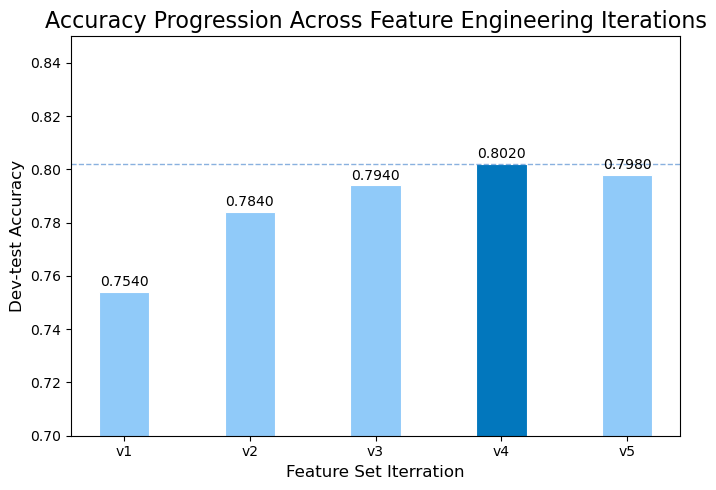

In [32]:
import matplotlib.pyplot as plt

iterations = ['v1', 'v2', 'v3', 'v4', 'v5']
accuracies = [devtest_acc_v1, devtest_acc_v2, devtest_acc_v3, devtest_acc_v4, devtest_acc_v5]
colors = ['#90CAF9', '#90CAF9', '#90CAF9', '#0277BD', '#90CAF9']  # v4 highlighted dark

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(versions, accuracies, color=colors, edgecolor='white', linewidth=0.8, width=0.4)
ax.set_ylim(0.70, 0.85)
ax.set_xlabel('Feature Set Iterration', fontsize=12)
ax.set_ylabel('Dev-test Accuracy', fontsize=12)
ax.set_title('Accuracy Progression Across Feature Engineering Iterations', fontsize=16, fontweight='normal')

# Add value labels on top of each bar
for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{acc:.4f}', ha='center', va='bottom', fontsize=10)

ax.axhline(y=devtest_acc_v4, color='#1565C0', linestyle='--', linewidth=1, alpha=0.5)
plt.tight_layout()
plt.show()

### Final Evaluation on the Test Set

Having selected the best-performing feature set (v4), I now evaluate it on the **held-out test set.** 
This gives an unbiased estimate of real-world performance.

### Final Test Set Evaluation

In [19]:
test_set = [(gender_features_v4(n), g) for (n, g) in test_names]

test_acc = nltk.classify.accuracy(classifier_v4, test_set)
print(f"Final dev-test accuracy: {devtest_acc_v4:.4f}")
print(f"Final test set accuracy: {test_acc:.4f}")
print(f"Difference:              {abs(devtest_acc_v4 - test_acc):.4f}")

Final dev-test accuracy: 0.8020
Final test set accuracy: 0.7920
Difference:              0.0100


### Dev-test vs Test Set Comparison


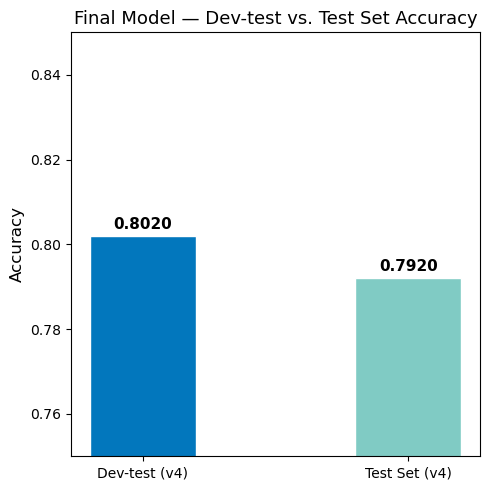

In [33]:
fig, ax = plt.subplots(figsize=(5, 5))
labels = ['Dev-test (v4)', 'Test Set (v4)']
scores = [devtest_acc_v4, test_acc]
colors = ['#0277BD', '#80CBC4']

bars = ax.bar(labels, scores, color=colors, width=0.4, edgecolor='white')
ax.set_ylim(0.75, 0.85)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Final Model — Dev-test vs. Test Set Accuracy', fontsize=13, fontweight='normal')

for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{score:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

---

## Final Model Selection

Feature engineering was conducted across five iterations, with dev-test accuracy measured 
after each refinement. V4 — incorporating first letter, last letter, last two letters, 
last three letters, name length, and vowel count — achieved the highest dev-test accuracy 
at **80.20%** and was selected as the final model.

V5 introduced explicit boolean suffix flags for common gendered endings (*-a*, *-ia*, 
*-ina*, *-on*, *-en*, *-er*, *-son*). Rather than improving performance, v5 produced a 
lower dev-test accuracy of **79.80%** — a regression of 0.4 percentage points. This 
outcome confirmed that the suffix flags were redundant with information already captured 
by the bigram and trigram suffix features introduced in v2 and v3. In a Naive Bayes model, 
encoding the same signal twice does not reinforce it — it dilutes the probability 
calculations and can modestly hurt performance. V4 was therefore selected as the final model 
on the basis of empirical evidence from the dev-test set.

---

### Final Evaluation Results

| Metric | Score |
|--------|-------|
| Dev-test Accuracy (v4) | 80.20% |
| Test Set Accuracy (v4) | 79.20% |
| Difference | 1.00 percentage point |

The test set was held out for the entirety of the feature engineering process and was 
used exactly once — for final evaluation. The classifier correctly predicted gender for 
**396 out of 500 completely unseen names**.

---

### Dev-test vs. Test Set Performance

The 1 percentage point gap between dev-test and test set accuracy is both expected and 
acceptable. Because feature decisions across five iterations were guided by dev-test 
feedback, a mild bias toward that specific 500-name sample is an inherent consequence of 
the process. The test set, having never influenced any modeling decision, provides a fully 
unbiased estimate of generalization performance.

A gap of this magnitude confirms two things. First, the dev-test set fulfilled its intended 
role as a tuning guide — it correctly identified v4 as the strongest feature set. Second, 
the model did not overfit to the dev-test set. A substantially larger gap would indicate 
over-reliance on dev-test-specific patterns and would undermine confidence in the model's 
ability to generalize. A gap of 1 point indicates the model generalizes well to unseen data.

---

### Classifier Selection and Performance Interpretation

Three classifiers are described in Chapter 6 of *Natural Language Processing with Python*:

- **Decision Tree** (`nltk.DecisionTreeClassifier`)
- **Naive Bayes** (`nltk.NaiveBayesClassifier`)
- **Maximum Entropy** (`nltk.MaxentClassifier`)

Naive Bayes was selected for three reasons. First, it handles sparse, high-dimensional 
feature spaces efficiently — character-level features like letter suffixes produce exactly 
this kind of space. Second, it trains fast enough to support rapid iteration across 
multiple dev-test evaluation cycles, which is essential when making incremental feature 
refinements. Third, it produces interpretable feature importance rankings via 
`show_most_informative_features()`, allowing each iteration to inform the next.

The consistent accuracy gains from v1 through v4 — from **75.40% to 80.20%** — validate 
this choice. The character-level features used in this classifier are relatively independent 
of one another, which aligns well with the conditional independence assumption that Naive 
Bayes relies on. Where that assumption was violated — as in v5, where suffix flags 
duplicated existing bigram and trigram features — performance declined, further 
demonstrating the model's sensitivity to feature redundancy.